In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


DATA_DIR = Path("data/wisdm-dataset")

RAW_DATA_DIR = DATA_DIR / "raw"


ACTIVITY_MAP = {
    "A": "walking",
    "B": "jogging",
    "C": "stairs",
    "D": "sitting",
    "E": "standing",
    "F": "typing",
    "G": "teeth",
    "H": "soup",
    "I": "chips",
    "J": "pasta",
    "K": "drinking",
    "L": "sandwich",
    "M": "kicking",
    "O": "catch",
    "P": "dribbling",
    "Q": "writing",
    "R": "clapping",
    "S": "folding",
}

ACTIVITIES = list(ACTIVITY_MAP.keys())

In [4]:
ACTIVITIES

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'O',
 'P',
 'Q',
 'R',
 'S']

In [5]:
ACTIVITY_MAP

{'A': 'walking',
 'B': 'jogging',
 'C': 'stairs',
 'D': 'sitting',
 'E': 'standing',
 'F': 'typing',
 'G': 'teeth',
 'H': 'soup',
 'I': 'chips',
 'J': 'pasta',
 'K': 'drinking',
 'L': 'sandwich',
 'M': 'kicking',
 'O': 'catch',
 'P': 'dribbling',
 'Q': 'writing',
 'R': 'clapping',
 'S': 'folding'}

In [18]:
devices = (
    "phone",
    "watch",
)
sensors = (
    "accel",
    "gyro",
)
COLUMNS = ["id", "activity", "timestamp", "x", "y", "z"]

### Accel

- Provides the acceleration along the three axis based on the devices
- m/s^2

### Gyro

- Provides the angular velocity on each axis based on the device
- rad/s

### Magnitude

sq(x^2 + y^2 + z^2)


In [19]:
def magnitude(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)


def estimate_hz(df: pd.DataFrame) -> float:
    dts = df.groupby("activity", sort=False)["timestamp"].diff().dropna()
    med = dts.median()
    return float(1e9 / med) if med and med > 0 else float("nan")


def load_data(file_path: Path):
    df = pd.read_csv(
        file_path,
        header=None,
        names=COLUMNS,
        converters={"z": lambda z: str(z).rstrip(";")},  # remove the last ; line break
    )
    df["activity_name"] = df["activity"].map(ACTIVITY_MAP)
    df["z"] = df["z"].astype(float)
    df["magnitude"] = magnitude(df["x"], df["y"], df["z"])
    return df

In [20]:
# Each data files study on 51 subjects for 4 streams: device and sensor
rows = []
for device in devices:
    for sensor in sensors:
        for path in sorted((RAW_DATA_DIR / device / sensor).glob("data_*.txt")):
            tmp = load_data(path)
            acts = set(tmp["activity"])
            rows.append(
                {
                    "device": device,
                    "sensor": sensor,
                    "subject": int(tmp["id"].iloc[0]),
                    "n_rows": len(tmp),
                    "n_acts": tmp["activity"].nunique(),
                    "missing": ",".join(
                        ACTIVITY_MAP.get(a, "UNIDENTIFIED")
                        for a in ACTIVITIES
                        if a not in acts
                    ),
                    "hz": estimate_hz(tmp),
                    "null_xyz": int(tmp[["x", "y", "z"]].isna().any(axis=1).sum()),
                }
            )

inv = pd.DataFrame(rows)

## Missing Informations

In [9]:
print(
    inv[inv["n_acts"] != 18][["device", "sensor", "subject", "n_acts", "missing", "hz"]]
)
print("\nPhone accel Hz buckets:")
print(
    inv.query("device=='phone' and sensor=='accel'")["hz"]
    .round()
    .value_counts()
    .sort_index()
)

    device sensor  subject  n_acts          missing         hz
7    phone  accel     1607      17            pasta  25.059388
9    phone  accel     1609      17          jogging  19.859394
16   phone  accel     1616      16   jogging,typing  49.648484
18   phone  accel     1618      17            catch  19.859394
42   phone  accel     1642      16    stairs,typing  49.761146
43   phone  accel     1643      17            chips  49.761146
58   phone   gyro     1607      17            pasta  25.059417
60   phone   gyro     1609      17          jogging  19.859394
67   phone   gyro     1616      16   jogging,typing  19.859394
69   phone   gyro     1618      17            catch  19.859394
92   phone   gyro     1641      17          writing  24.817591
93   phone   gyro     1642      16    stairs,typing  24.814512
94   phone   gyro     1643      17            chips  24.810202
95   phone   gyro     1644      17         sandwich  24.812049
118  watch  accel     1616      17          jogging  20

#### Class Imbalance check

In [10]:
# for device phone and sensor accel
phone_accel = []
for path in sorted((RAW_DATA_DIR / "phone" / "accel").glob("data_*.txt")):
    tmp = load_data(path)
    phone_accel.append(tmp["activity_name"].value_counts())
counts = pd.concat(phone_accel, axis=1).sum(axis=1).sort_values()

counts = counts.rename("n_samples")
counts.to_frame().assign(pct=lambda d: 100 * d["n_samples"] / d["n_samples"].sum())

,n_samples,pct
activity_name,,
typing,246356.0,5.127713
pasta,249793.0,5.199252
stairs,255645.0,5.321057
writing,260497.0,5.422047
chips,261360.0,5.440010
sitting,264592.0,5.507282
folding,265214.0,5.520228
sandwich,265781.0,5.532030
clapping,268065.0,5.579569


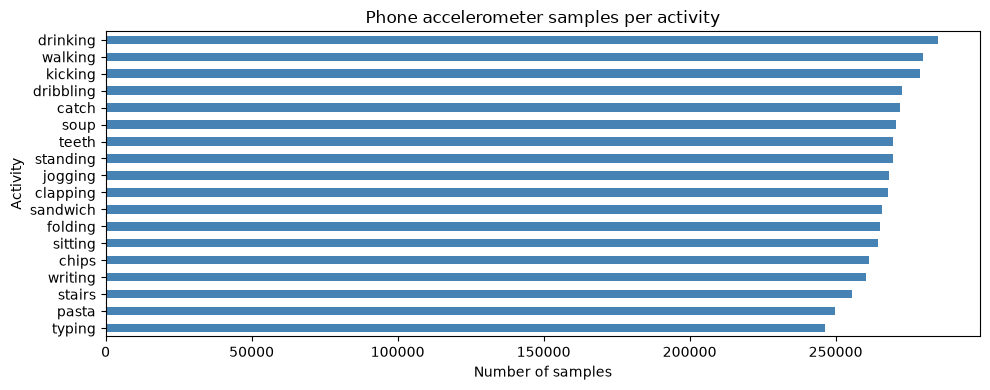

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Phone accelerometer samples per activity")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Activity")
plt.tight_layout()
plt.show()

## CNN-BiLSTM Model for Human Activity Recognition

Pipeline:
1. Segment the phone accelerometer stream (per subject/activity) into fixed-length sliding windows.
2. Split windows by **subject** (not randomly) to avoid data leakage, then standardize features.
3. Feed windows through a **CNN-BiLSTM** hybrid: `Conv1d` layers extract local spatial/temporal patterns,
   a **BiLSTM** captures long-range temporal dependencies, and a final dense (`Linear`) layer produces
   class logits which are turned into probabilities via **softmax**.
4. Train with categorical cross-entropy loss (`nn.CrossEntropyLoss`, which combines `log_softmax` + NLL loss).
5. Evaluate with accuracy, precision, recall and F1-score (macro-averaged).

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
WINDOW_SIZE = 200  # ~10s @ 20Hz, matches WISDM's reported phone accel sampling rate
STRIDE = 100  # 50% overlap
FEATURE_COLS = ["x", "y", "z", "magnitude"]

DEVICE


device(type='mps')

In [22]:
def make_windows(df: pd.DataFrame, window_size: int, stride: int):
    """Slice a single (subject, activity) stream into fixed-length overlapping windows."""
    values = df[FEATURE_COLS].to_numpy(dtype=np.float32)
    n = len(values)
    windows = []
    for start in range(0, n - window_size + 1, stride):
        windows.append(values[start : start + window_size])
    return windows


X_list, y_list, subject_list = [], [], []
for path in sorted((RAW_DATA_DIR / "phone" / "accel").glob("data_*.txt")):
    tmp = load_data(path)
    subject_id = int(tmp["id"].iloc[0])
    for activity, group in tmp.groupby("activity", sort=False):
        group = group.dropna(subset=FEATURE_COLS)
        for window in make_windows(group, WINDOW_SIZE, STRIDE):
            X_list.append(window)
            y_list.append(activity)
            subject_list.append(subject_id)

X = np.stack(X_list)  # (n_windows, window_size, n_features)
subjects = np.array(subject_list)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_list)

X.shape, y.shape, len(label_encoder.classes_)


((46691, 200, 4), (46691,), 18)

In [23]:
# Subject-wise split: hold out ~20% of subjects entirely for testing to avoid leakage
rng = np.random.default_rng(42)
unique_subjects = np.unique(subjects)
rng.shuffle(unique_subjects)
n_test_subjects = max(1, int(0.2 * len(unique_subjects)))
test_subjects = set(unique_subjects[:n_test_subjects])
train_mask = ~np.isin(subjects, list(test_subjects))
test_mask = ~train_mask

X_train_raw, X_test_raw = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Standardize per-feature using train statistics only
scaler = StandardScaler()
n_features = X_train_raw.shape[-1]
scaler.fit(X_train_raw.reshape(-1, n_features))
X_train = scaler.transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape).astype(np.float32)
X_test = scaler.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape).astype(np.float32)

print(f"Train windows: {X_train.shape}, Test windows: {X_test.shape}")
print(f"Train subjects: {len(unique_subjects) - n_test_subjects}, Test subjects: {n_test_subjects}")


class HARWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)  # (n, window, features)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64
train_loader = DataLoader(HARWindowDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(HARWindowDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)


Train windows: (36138, 200, 4), Test windows: (10553, 200, 4)
Train subjects: 41, Test subjects: 10


In [24]:
class CNNBiLSTM(nn.Module):
    """CNN front-end for spatial/local feature extraction + BiLSTM for temporal context."""

    def __init__(self, n_features: int, n_classes: int, cnn_channels: int = 64, lstm_hidden: int = 128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_features, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.classifier = nn.Linear(lstm_hidden * 2, n_classes)

    def forward(self, x):
        # x: (batch, window, features) -> Conv1d expects (batch, features, window)
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)  # back to (batch, seq, channels) for the LSTM
        _, (h_n, _) = self.lstm(x)
        h_forward, h_backward = h_n[-2], h_n[-1]
        h = torch.cat([h_forward, h_backward], dim=1)
        return self.classifier(h)  # logits; softmax is applied via CrossEntropyLoss / at inference

    def predict_proba(self, x):
        return torch.softmax(self.forward(x), dim=1)


model = CNNBiLSTM(n_features=len(FEATURE_COLS), n_classes=len(label_encoder.classes_)).to(DEVICE)
model


CNNBiLSTM(
  (conv): Sequential(
    (0): Conv1d(4, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(64, 128, batch_first=True, bidirectional=True)
  (classifier): Linear(in_features=256, out_features=18, bias=True)
)

In [28]:
criterion = nn.CrossEntropyLoss()  # categorical cross-entropy over softmax(logits)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            all_preds.append(logits.argmax(dim=1).cpu().numpy())
            all_labels.append(yb.cpu().numpy())
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(labels)
    acc = accuracy_score(labels, preds)
    return avg_loss, acc


N_EPOCHS = 500
PATIENCE = 15  # EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

best_val_loss = float("inf")
best_state_dict = None
epochs_without_improvement = 0

history = []
for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    history.append(
        {"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "test_loss": test_loss, "test_acc": test_acc}
    )
    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"| test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
    )

    if test_loss < best_val_loss:
        best_val_loss = test_loss
        best_state_dict = {k: v.detach().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)  # restore_best_weights=True

history_df = pd.DataFrame(history)

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = MODEL_DIR / "cnn_bilstm_har.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_config": {
            "n_features": len(FEATURE_COLS),
            "n_classes": len(label_encoder.classes_),
        },
        "feature_cols": FEATURE_COLS,
        "window_size": WINDOW_SIZE,
        "stride": STRIDE,
        "label_classes": label_encoder.classes_,
        "scaler_mean": scaler.mean_,
        "scaler_scale": scaler.scale_,
        "history": history,
        "best_val_loss": best_val_loss,
    },
    CHECKPOINT_PATH,
)
print(f"Saved best model checkpoint to {CHECKPOINT_PATH}")


Epoch 01/500 | train_loss=0.9385 train_acc=0.6522 | test_loss=3.3393 test_acc=0.2719
Epoch 02/500 | train_loss=0.8944 train_acc=0.6669 | test_loss=3.3698 test_acc=0.2776
Epoch 03/500 | train_loss=0.8875 train_acc=0.6719 | test_loss=3.4449 test_acc=0.2699
Epoch 04/500 | train_loss=0.8436 train_acc=0.6868 | test_loss=3.3267 test_acc=0.2763
Epoch 05/500 | train_loss=0.8159 train_acc=0.6949 | test_loss=3.3262 test_acc=0.2841
Epoch 06/500 | train_loss=0.7795 train_acc=0.7083 | test_loss=3.5616 test_acc=0.2768
Epoch 07/500 | train_loss=0.7684 train_acc=0.7127 | test_loss=3.6954 test_acc=0.2711
Epoch 08/500 | train_loss=0.7437 train_acc=0.7239 | test_loss=3.6946 test_acc=0.2848
Epoch 09/500 | train_loss=0.7186 train_acc=0.7307 | test_loss=3.7705 test_acc=0.2834
Epoch 10/500 | train_loss=0.6952 train_acc=0.7415 | test_loss=3.9300 test_acc=0.2847
Epoch 11/500 | train_loss=0.6716 train_acc=0.7475 | test_loss=4.0797 test_acc=0.2604
Epoch 12/500 | train_loss=0.6524 train_acc=0.7560 | test_loss=3.9

KeyboardInterrupt: 

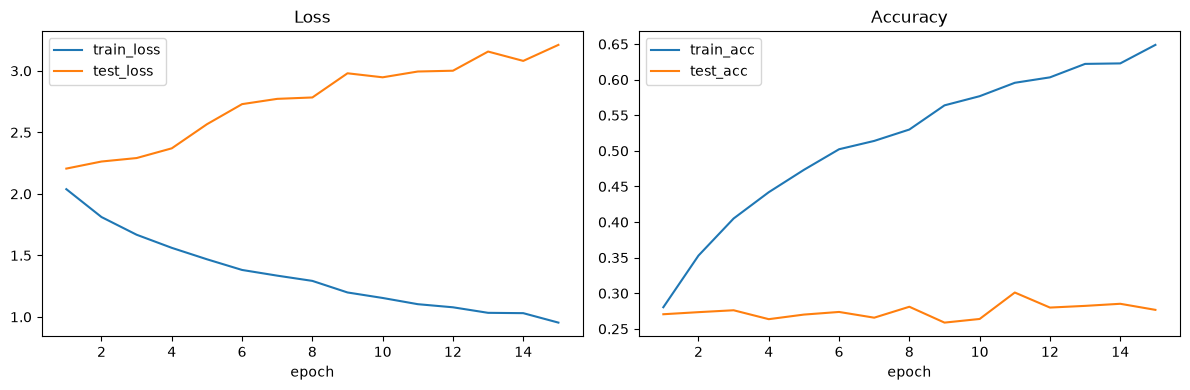

Accuracy:  0.2718
Precision: 0.2964
Recall:    0.2760
F1-score:  0.2781

              precision    recall  f1-score   support

     walking       0.91      0.67      0.77       577
     jogging       0.93      0.79      0.86       577
      stairs       0.54      0.83      0.65       523
     sitting       0.18      0.16      0.17       577
    standing       0.21      0.34      0.26       630
      typing       0.12      0.19      0.15       630
       teeth       0.13      0.08      0.10       631
        soup       0.04      0.03      0.03       577
       chips       0.12      0.14      0.13       573
       pasta       0.03      0.05      0.04       533
    drinking       0.00      0.00      0.00       577
    sandwich       0.07      0.03      0.04       577
     kicking       0.66      0.47      0.55       577
       catch       0.41      0.22      0.29       577
   dribbling       0.41      0.40      0.41       578
     writing       0.06      0.05      0.06       631
    clap

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df.plot(x="epoch", y=["train_loss", "test_loss"], ax=axes[0], title="Loss")
history_df.plot(x="epoch", y=["train_acc", "test_acc"], ax=axes[1], title="Accuracy")
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    test_logits = model(torch.from_numpy(X_test).to(DEVICE))
    test_preds = test_logits.argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_test, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_preds, average="macro", zero_division=0)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print(
    classification_report(
        y_test,
        test_preds,
        labels=range(len(label_encoder.classes_)),
        target_names=[ACTIVITY_MAP[c] for c in label_encoder.classes_],
        zero_division=0,
    )
)
